# Q2 Visualizations

To what extent are the applicant demographics driven by CHAPA’s limited property pool (suburban, age-restricted homes) versus applicant choice?

Author: Gia Bao (Belinda) Ngo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Merge Applicant and Resale&Price datasets

In [164]:
# Step 1: Load datasets
# Property dataset with price & resale info
df_properties = pd.read_csv("../data/allprice_resale_2021-25_final_latest.csv")
# Applicant dataset for Chapter 40B properties
df_applicants = pd.read_csv("../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv")


# Step 2: Standardize columns for merging
# Function to clean text columns (strip spaces, convert to lowercase)
def clean_text(series):
    return series.astype(str).str.strip().str.lower()

# Clean property dataset columns
df_properties['Town_clean'] = clean_text(df_properties['Town'])
df_properties['Address_clean'] = clean_text(df_properties['Address'])
df_properties['Unit_clean'] = clean_text(df_properties['Unit Number'])

# Clean applicant dataset columns
df_applicants['Town_clean'] = clean_text(df_applicants['property_town_city'])
df_applicants['Address_clean'] = clean_text(df_applicants['property_street_address'])
df_applicants['Unit_clean'] = clean_text(df_applicants['property_unit'])


# Step 3: Merge applicants onto properties
merged = pd.merge(
    df_properties,
    df_applicants,
    on=['Town_clean', 'Address_clean', 'Unit_clean'],
    how='right',
    suffixes=('', '_applicant')
)

# Drop the temporary cleaned columns
merged = merged.drop(columns=['Town_clean', 'Address_clean', 'Unit_clean'])

# Save intermediate merge
merged.to_csv("../data/merged_Chapter-40B-v0.3_allprice_resale.csv", index=False)
print("Merge complete. File saved as merged_Chapter-40B-v0.3_allprice_resale.csv")

# Step 4: Add missing Maximum Resale Prices
## Load the merged dataset and new price data
merged_final = pd.read_csv("../data/merged_Chapter-40B-v0.3_allprice_resale.csv")
df_prices = pd.read_csv("../data/Property_Data_Jun2021_Sep2025_MissingResaleValues_Completed.csv")

# Rename column for clarity
df_prices = df_prices.rename(columns={"Price": "Maximum Resale Price"})

# Define keys to merge on
merge_keys = ["Town", "Address", "Unit Number"]

# Merge new prices into the dataset
merged_updated = pd.merge(
    merged_final,
    df_prices[merge_keys + ["Maximum Resale Price"]],
    on=merge_keys,
    how="left",
    suffixes=("", "_new")
)

# Fill missing prices with values from new dataset
merged_updated["Maximum Resale Price"] = merged_updated["Maximum Resale Price"].fillna(
    merged_updated["Maximum Resale Price_new"]
)

# Drop the helper column
merged_updated = merged_updated.drop(columns=["Maximum Resale Price_new"])

# Save the final dataset
merged_updated.to_csv("../data/merged_filled_Chapter-40B-v0.3_allprice_resale.csv", index=False)
print("Missing prices filled. File saved as merged_filled_Chapter-40B-v0.3_allprice_resale.csv")

Merge complete. File saved as merged_Chapter-40B-v0.3_allprice_resale.csv
Missing prices filled. File saved as merged_filled_Chapter-40B-v0.3_allprice_resale.csv


## Using Merged Applicant and Property&Price dataset

In [166]:
file_path = "../data/merged_filled_Chapter-40B-v0.3_allprice_resale.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
print(len(df))
df = df.dropna(subset=['town'])
print(len(df))
df.head()

1614
901


,town,address,unit_number,maximum_resale_price,property_feature,development,transaction_start_date,closing_date,bedrooms,age_restricted,...,race_cleaned,race_type,race_american_indian_or_alaska_native,race_asian,race_black_or_african_american,race_hispanic_or_latino,race_middle_eastern_or_north_african,race_native_hawaiian_or_pacific_islander,race_other__prefer_not_to_answer,race_white
14,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
15,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
16,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
17,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
19,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,"['Asian', 'Native Hawaiian or Pacific Islander']",Multiracial,0,1,0,0,0,1,0,0


### Race vs. Property restriction

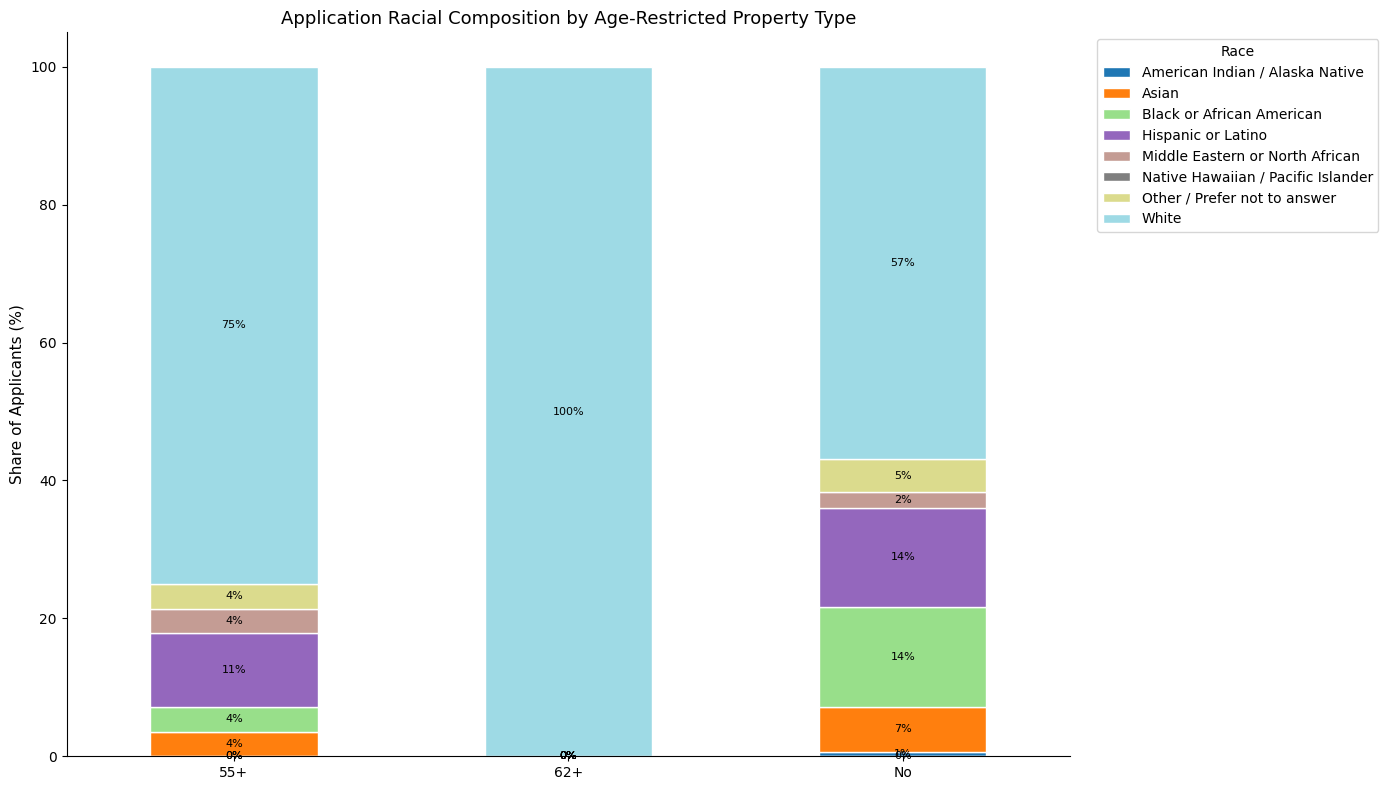

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to relevant subset
df_source = df[df['age_restricted'].notna() & (df['race_type'] == 'Single Race')]

race_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander',
    'race_other__prefer_not_to_answer',
    'race_white'
]

# Aggregate and compute within-group percentages
source_race = (
    df_source.groupby('age_restricted')[race_cols]
    .sum()
    .reset_index()
)

source_race_pct = source_race.copy()
source_race_pct[race_cols] = (
    source_race[race_cols]
    .div(source_race[race_cols].sum(axis=1), axis=0) * 100
)

# Define cleaner race labels
race_labels = [
    'American Indian / Alaska Native', 'Asian', 'Black or African American',
    'Hispanic or Latino', 'Middle Eastern or North African',
    'Native Hawaiian / Pacific Islander', 'Other / Prefer not to answer', 'White'
]

# Use seaborn color palette for clarity
colors = sns.color_palette("Set2", len(race_cols))

# Plot
ax = source_race_pct.set_index('age_restricted')[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap = 'tab20',
    edgecolor='white'
)

# Style tweaks
ax.set_ylabel('Share of Applicants (%)', fontsize=11)
ax.set_xlabel('')
ax.set_title('Application Racial Composition by Age-Restricted Property Type', fontsize=13)#, weight='bold')
ax.legend(race_labels, title='Race', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels inside bars (optional, can comment out if cluttered)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='black', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

### Age vs. Property Town

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_2998/2284039599.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


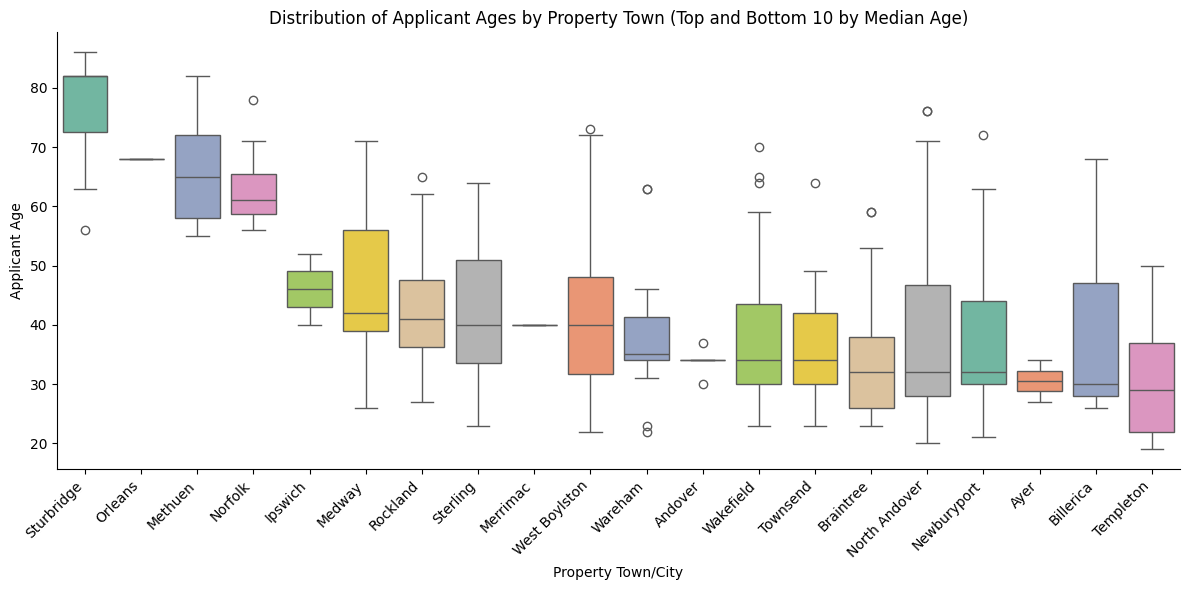

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter: drop missing ages or locations
df_age = df[df['age'].notna() & df['property_town_city'].notna() & df['age_restricted'].notna()].copy()

# Option 1: Show top 10 and bottom 10 towns by average age
age_by_town = (
    df_age.groupby('property_town_city')['age']
    .median()
    .sort_values(ascending=False)
)
top_towns = pd.concat([age_by_town.head(10), age_by_town.tail(10)]).index
df_towns_subset = df_age[df_age['property_town_city'].isin(top_towns)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_towns_subset,
    x='property_town_city',
    y='age',
    order=age_by_town.loc[top_towns].index,
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Property Town/City')
plt.ylabel('Applicant Age')
plt.title('Distribution of Applicant Ages by Property Town (Top and Bottom 10 by Median Age)')#, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

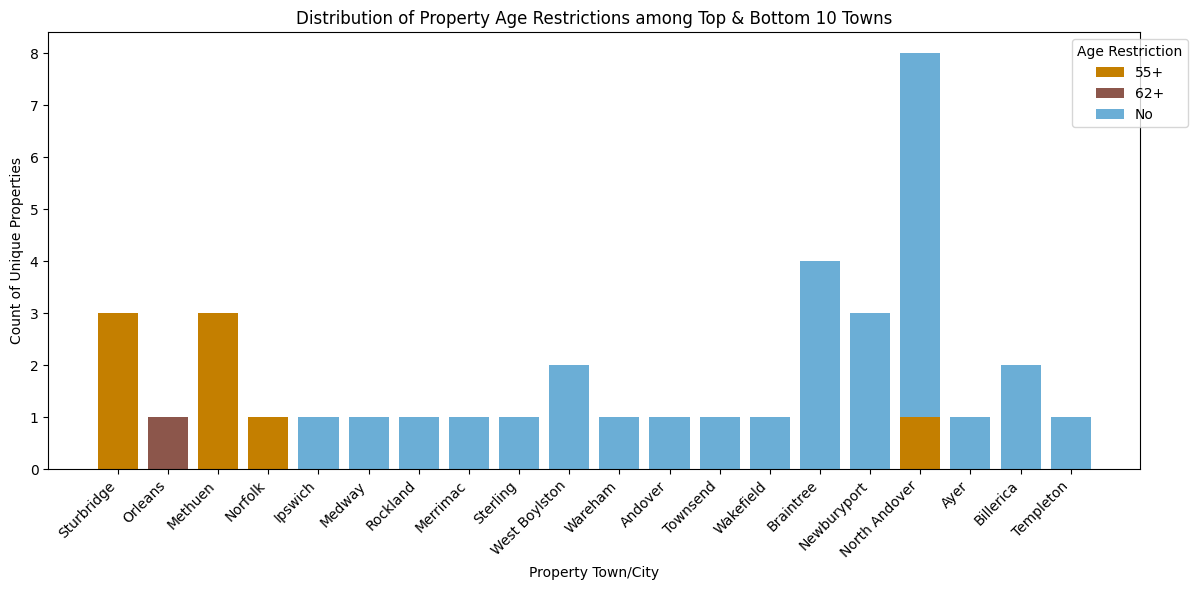

In [211]:
df_clean = df.copy()

# Normalize key components
for col in ['property_town_city', 'property_street_address', 'property_unit']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Create unique property key
df_clean['property_key'] = (
    df_clean['property_town_city'] + ' | ' +
    df_clean['property_street_address'] + ' | ' +
    df_clean['property_unit']
)

df_clean['age_restricted'] = (
    df_clean['age_restricted']
    .astype(str)
    .str.strip()
    .replace({'nan': None, '': None, 'None': None})
)

unique_props = (
    df_clean.groupby('property_key')
    .agg({
        'property_town_city': 'first',
        'age_restricted': lambda x: (
            '55+' if '55+' in x.values else
            ('62+' if '62+' in x.values else 'No')
        )
    })
    .reset_index()
)

age_by_town = (
    df_age.groupby('property_town_city')['age']
    .median()
    .sort_values(ascending=False)
)
towns_of_interest = pd.concat([age_by_town.head(10), age_by_town.tail(10)]).index

# Filter unique properties to those 20 towns
subset_props = unique_props[
    unique_props['property_town_city'].isin(towns_of_interest)
]

# Count properties by town × age restriction type
town_age_counts = (
    subset_props
    .groupby(['property_town_city', 'age_restricted'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

town_age_counts = (
    town_age_counts
    .merge(age_by_town.rename('median_age'), on='property_town_city', how='left')
    .sort_values('median_age', ascending=False)
)

town_age_counts

# # Melt the dataframe for plotting (long format)
# plot_df = town_age_counts.melt(
#     id_vars=['property_town_city', 'median_age'],
#     value_vars=['55+', '62+', 'No'],
#     var_name='Age Restriction',
#     value_name='Property Count'
# )

# # Plot
# plt.figure(figsize=(12,6))
# sns.barplot(
#     data=plot_df,
#     x='property_town_city',
#     y='Property Count',
#     hue='Age Restriction',
#     order=town_age_counts['property_town_city'],
#     palette=['#c47f00', '#8c564b', '#6baed6']  # custom colors: 55+, 62+, No
# )

# plt.title('Distribution of Property Age Restrictions among Top & Bottom 10 Towns', weight='bold')
# plt.xlabel('Property Town/City')
# plt.ylabel('Count of Unique Properties')
# plt.xticks(rotation=45, ha='right')
# plt.legend(title='Age Restriction', bbox_to_anchor=(1.05, 1))
# sns.despine()
# plt.tight_layout()
# plt.show()

towns = town_age_counts['property_town_city']
x = np.arange(len(towns))

# Get counts for each restriction type
counts_55 = town_age_counts['55+']
counts_62 = town_age_counts['62+']
counts_no = town_age_counts['No']

# Plot
plt.figure(figsize=(12,6))

plt.bar(x, counts_55, label='55+', color='#c47f00')
plt.bar(x, counts_62, bottom=counts_55, label='62+', color='#8c564b')
plt.bar(x, counts_no, bottom=counts_55 + counts_62, label='No', color='#6baed6')

plt.xticks(x, towns, rotation=45, ha='right')
plt.xlabel('Property Town/City')
plt.ylabel('Count of Unique Properties')
plt.title('Distribution of Property Age Restrictions among Top & Bottom 10 Towns')
plt.legend(title='Age Restriction', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_2998/542362222.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_age_restricted'] = df_clean['age_restricted'].isin(['55+', '62+'])


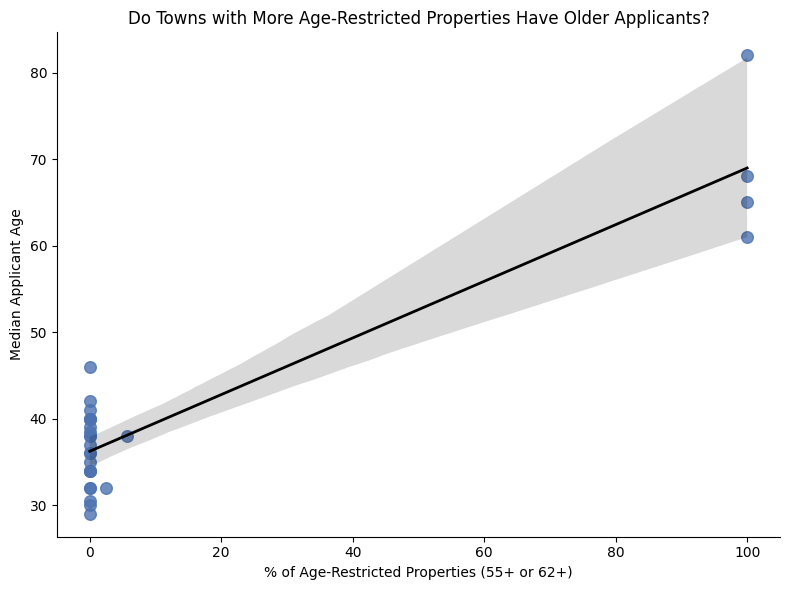

Correlation between % age-restricted and median applicant age: 0.92


In [201]:
df_clean = df[df['property_town_city'].notna() & df['age_restricted'].notna()]

# Create a binary flag: True if 55+ or 62+, else False
df_clean['is_age_restricted'] = df_clean['age_restricted'].isin(['55+', '62+'])

# Keep rows with non-missing age and property town
df_clean = df_clean[df_clean['age'].notna() & df_clean['property_town_city'].notna()]

# -------------------------------
# 2️⃣ Compute town-level median age
# -------------------------------

age_by_town = (
    df_clean.groupby('property_town_city')['age']
    .median()
    .reset_index()
    .rename(columns={'age': 'median_age'})
)

# -------------------------------
# 3️⃣ Compute % of age-restricted properties by town
# -------------------------------

town_age_restricted = (
    df_clean.groupby('property_town_city')['is_age_restricted']
    .mean()
    .reset_index()
    .rename(columns={'is_age_restricted': 'pct_age_restricted'})
)

town_age_restricted['pct_age_restricted'] *= 100  # convert to %

# -------------------------------
# 4️⃣ Merge both summaries
# -------------------------------

town_summary = (
    age_by_town
    .merge(town_age_restricted, on='property_town_city', how='left')
    .fillna({'pct_age_restricted': 0})
)

# -------------------------------
# 5️⃣ Visualize relationship
# -------------------------------

plt.figure(figsize=(8,6))
sns.regplot(
    data=town_summary,
    x='pct_age_restricted',
    y='median_age',
    scatter_kws={'s': 70, 'alpha': 0.8, 'color': '#4C72B0'},
    line_kws={'color': 'black', 'lw': 2}
)
plt.xlabel('% of Age-Restricted Properties (55+ or 62+)')
plt.ylabel('Median Applicant Age')
plt.title('Do Towns with More Age-Restricted Properties Have Older Applicants?')
sns.despine()
plt.tight_layout()
plt.show()

# -------------------------------
# 6️⃣ Correlation for quick test
# -------------------------------

corr = town_summary['pct_age_restricted'].corr(town_summary['median_age'])
print(f"Correlation between % age-restricted and median applicant age: {corr:.2f}")

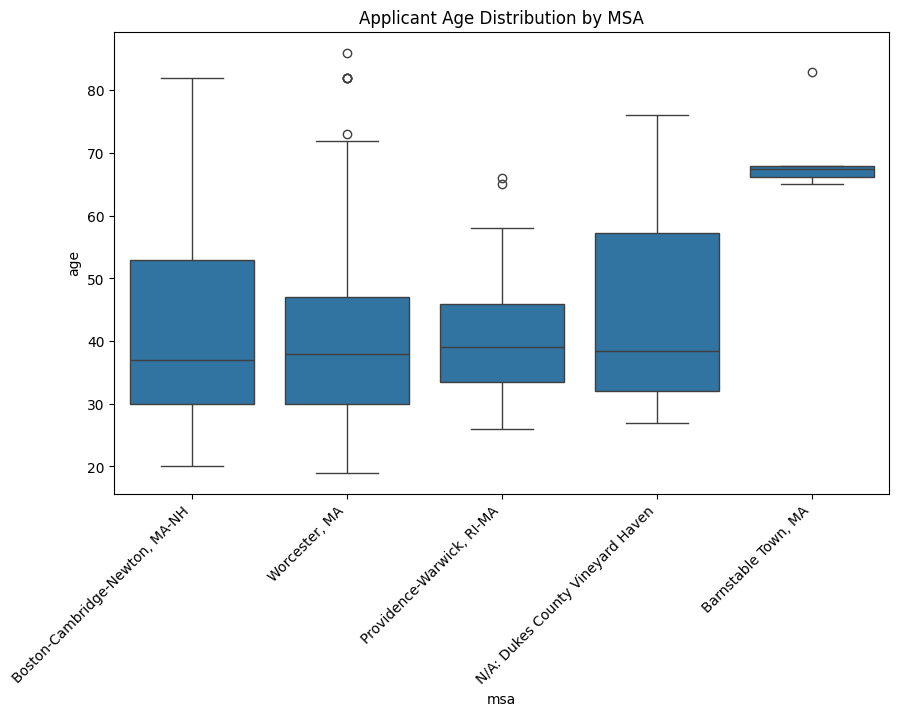

In [198]:
df.columns.values[49]
df.columns.values[20] = 'msa_alt'
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='msa', y='age')
plt.xticks(rotation=45, ha='right')
plt.title('Applicant Age Distribution by MSA')
plt.show()
df.columns.values[20] = 'msa'

## Using Applicant v0.3 dataset

In [163]:
file_path = "../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
print(len(df))
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
df.head()

1739


,id_number,submission_date,age,disability,chapa_races,census_races,current_residence_town_city,current_residence_state,current_residence_zip,application_source,...,race_cleaned,race_type,race_american_indian_or_alaska_native,race_asian,race_black_or_african_american,race_hispanic_or_latino,race_middle_eastern_or_north_african,race_native_hawaiian_or_pacific_islander,race_other__prefer_not_to_answer,race_white
0,150733,2022-02-08,65,0,White/Non-Minority,White alone,Somerville,MA,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1
1,439181,2022-02-08,59,0,Hispanic/Latino,Unknown,Westford,MA,NaN,Unknown,...,['Hispanic or Latino'],Single Race,0,0,0,1,0,0,0,0
4,226436,2022-02-08,60,0,White/Non-Minority,White alone,Nashua,NH,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1
6,170029,2021-06-15,35,0,White/Non-Minority,White alone,Waltham,MA,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1
8,569863,2021-06-15,38,0,Black or African American,Black or African American alone,Woburn,MA,NaN,Unknown,...,['Black or African American'],Single Race,0,0,1,0,0,0,0,0


### Are some Marketing Sources attracting Repeat vs Non-repeat Applicants?

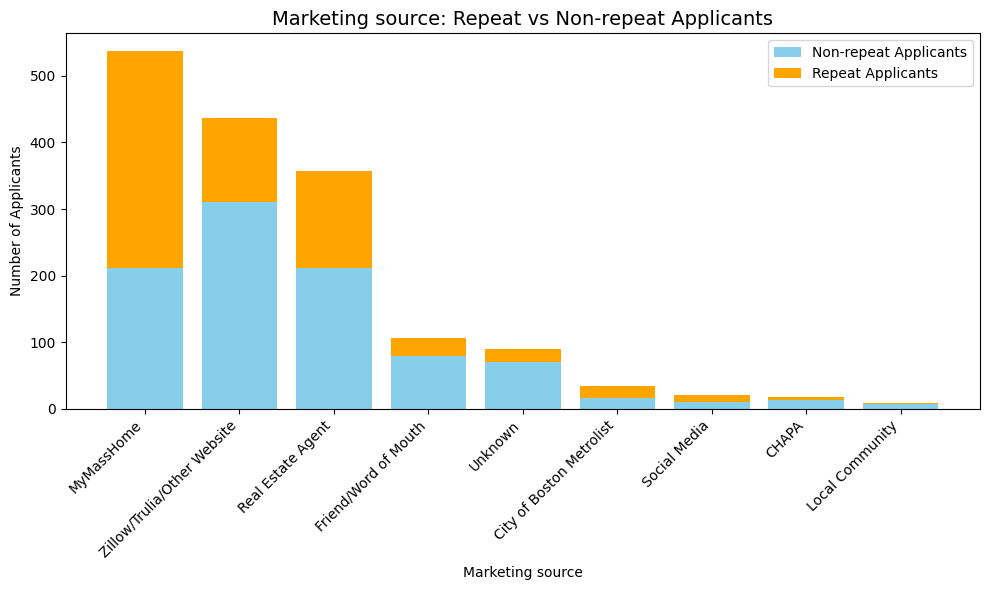

In [78]:
# total applications per town (count all rows)
all_applications = df.groupby('application_source')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('application_source')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).head(30).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(10,6))
plt.bar(top_30_towns, non_repeat_applications, color='skyblue', label='Non-repeat Applicants')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='orange', label='Repeat Applicants')

plt.title("Marketing source: Repeat vs Non-repeat Applicants", fontsize=14)
plt.ylabel("Number of Applicants")
plt.xlabel("Marketing source")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

### Do Repeat Applicants tend to apply to the same Town?

Top 30 Towns: Repeat vs Non-repeat Applicants

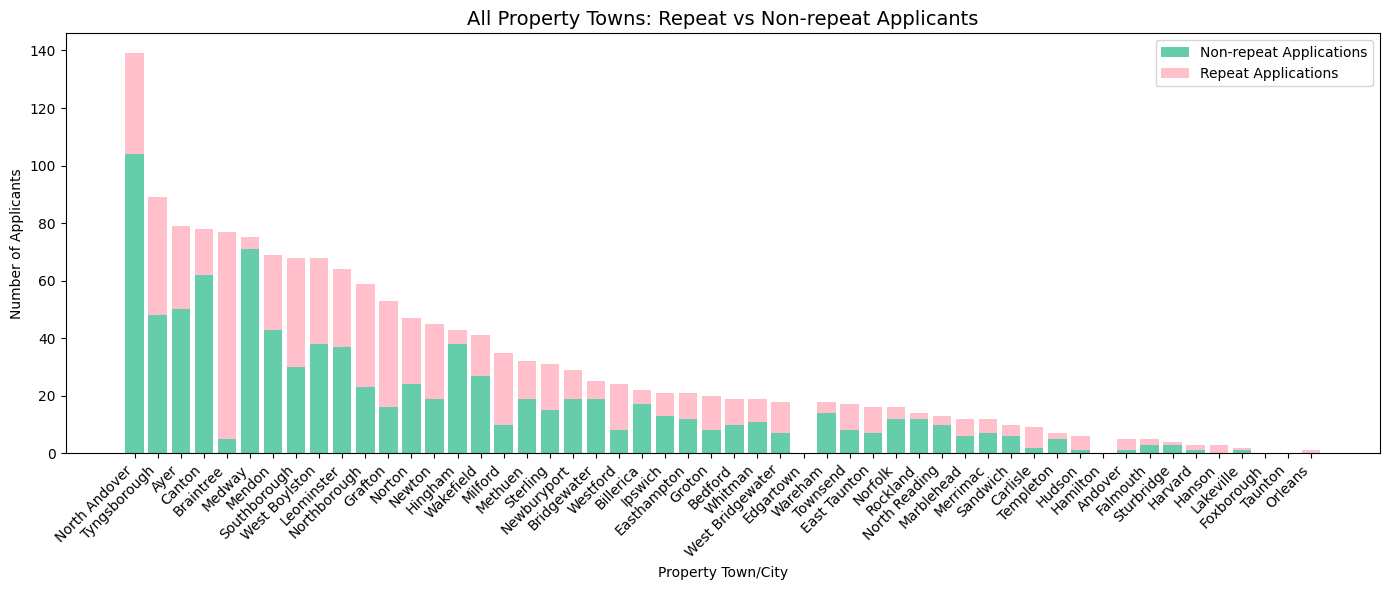

In [86]:
# total applications per town (count all rows)
all_applications = df.groupby('property_town_city')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('property_town_city')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(14,6))
plt.bar(top_30_towns, non_repeat_applications, color='mediumaquamarine', label='Non-repeat Applications')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='pink', label='Repeat Applications')

plt.title("All Property Towns: Repeat vs Non-repeat Applicants", fontsize=14)
plt.ylabel("Number of Applicants")
plt.xlabel("Property Town/City")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

### Which Town/City has the most Property listings?

In [87]:
col = "property_town_city"
df[col].nunique(), df[col].isnull().sum()

(52, np.int64(0))

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_2998/2781396610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


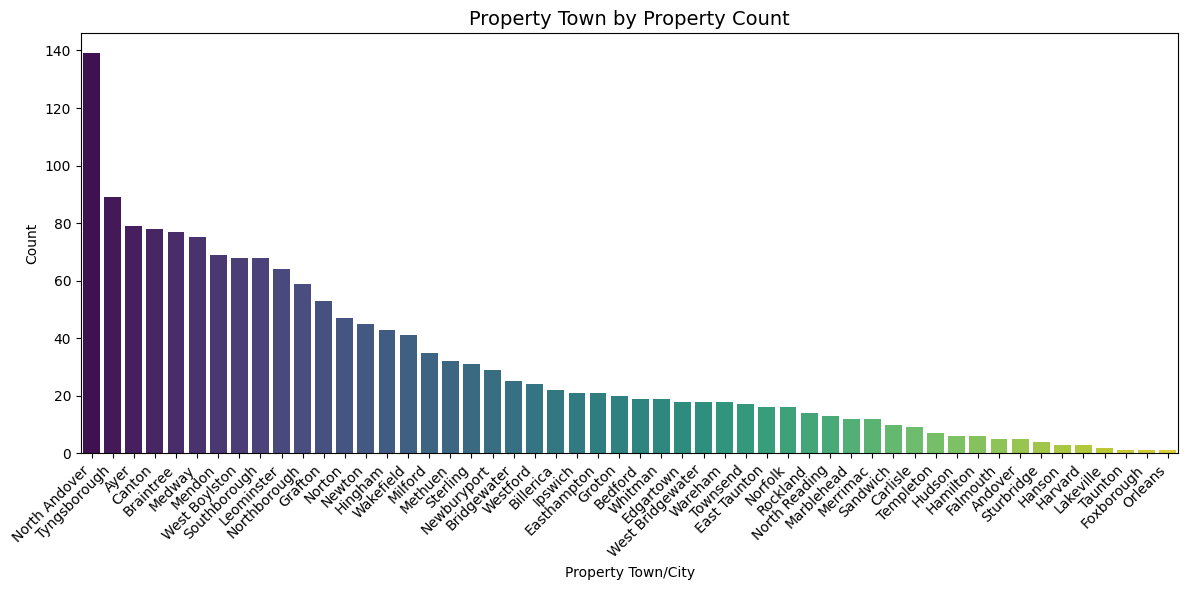

In [89]:
plt.figure(figsize=(12,6))

top_towns = df['property_town_city'].value_counts().index[:]

# Filter and define order
sns.countplot(
    data=df[df['property_town_city'].isin(top_towns)],
    x='property_town_city',
    order=top_towns,
    palette='viridis'
)

plt.title("Property Town by Property Count", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Property Town/City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Are certain Races applying to properties in the same Town/City?

In [106]:
df.columns.to_list()[-8:]
df['race_type'].value_counts()
1436 / len(df)

0.8924798011187073

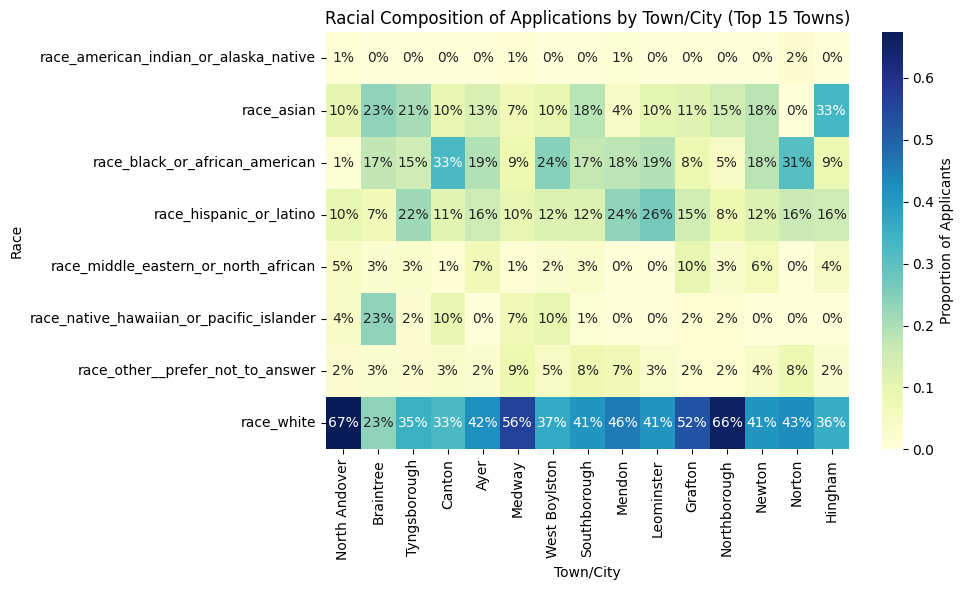

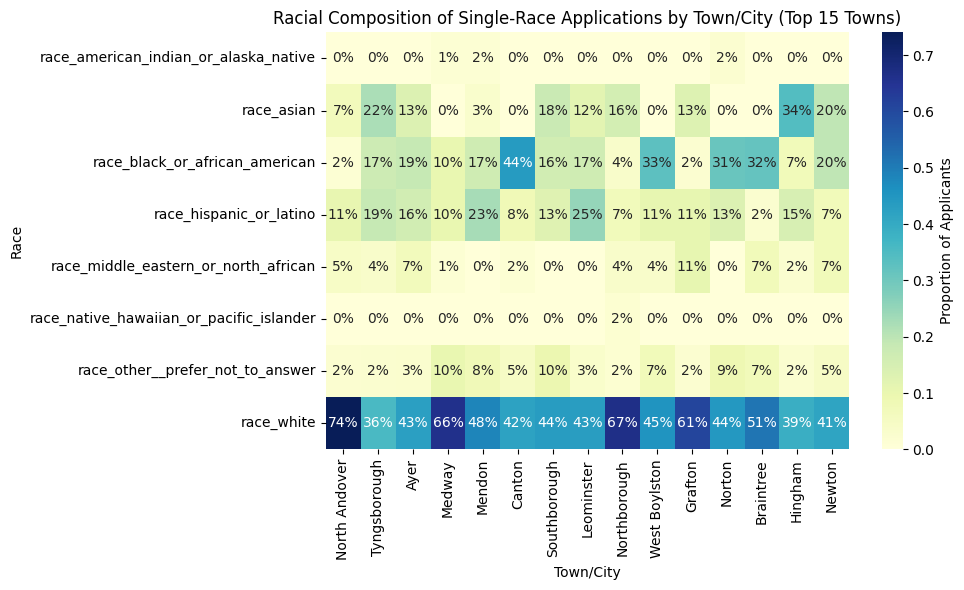

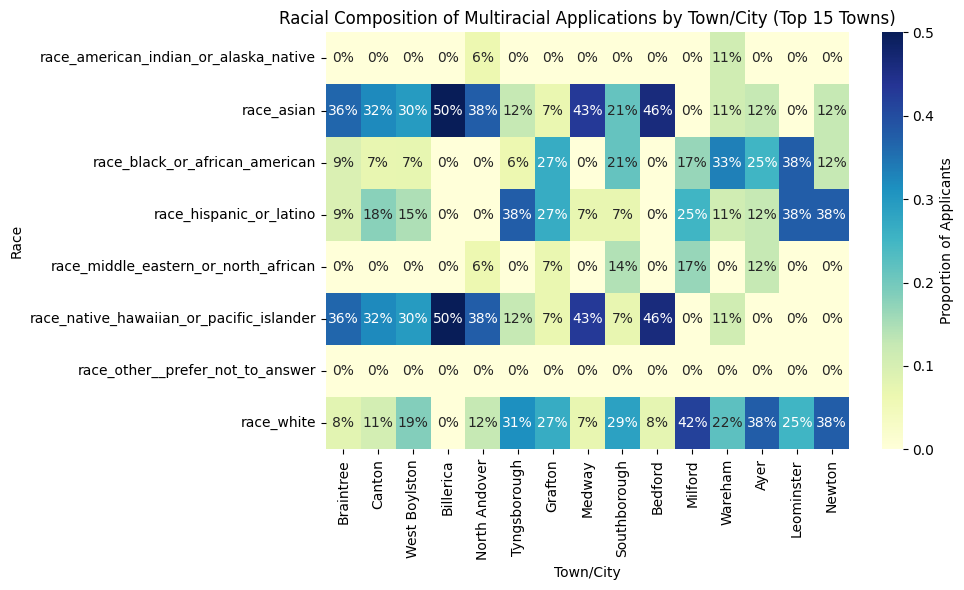

In [136]:
race_cols = df.columns.to_list()[-8:]

# Aggregate race counts per town
race_by_town = df.groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

# Single Race only
# Aggregate race counts per town
race_by_town = df[df['race_type'] == 'Single Race'].groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Single-Race Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

# Multiracial only
# Aggregate race counts per town
race_by_town = df[df['race_type'] == 'Multiracial'].groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Multiracial Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

# race_share_top_plot = race_share_top.reset_index().melt(
#     id_vars='property_town_city',
#     var_name='Race',
#     value_name='Proportion'
# )

# plt.figure(figsize=(12,6))
# sns.barplot(
#     data=race_share_top_plot,
#     x='property_town_city',
#     y='Proportion',
#     hue='Race'
# )
# plt.xticks(rotation=45, ha='right')
# plt.title("Racial Composition by Property Town/City (Top 15)")
# plt.xlabel("Property Town/City")
# plt.ylabel("Proportion of Applicants")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [101]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['property_town_city'], df['race_cleaned'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.2f}, p-value = {p:.4f}")
# p < 0.05 → race and town are not independent (i.e., some races cluster in certain towns).

Chi-square = 1695.32, p-value = 0.0000


In [103]:
import statsmodels.api as sm
from patsy import dmatrices

y, X = dmatrices('race_white ~ C(property_town_city)', data=df, return_type='dataframe')
model = sm.Logit(y, X).fit()
print(model.summary())

         Current function value: 0.640676
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:             race_white   No. Observations:                 1609
Model:                          Logit   Df Residuals:                     1557
Method:                           MLE   Df Model:                           51
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                 0.07139
Time:                        23:36:16   Log-Likelihood:                -1030.8
converged:                      False   LL-Null:                       -1110.1
Covariance Type:            nonrobust   LLR p-value:                 5.966e-13
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    18.0214   3662.847      0.005      0.

/Users/bgngo/DS701 CHAPA/ds-chapa-affordable-housing/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Are certain racial groups applying to properties in the same towns/cities, after accounting for how many properties are actually available in each town?

### Are certain Marketing sources attracting certain Races? Repeat vs. Non-repeat Applicants?

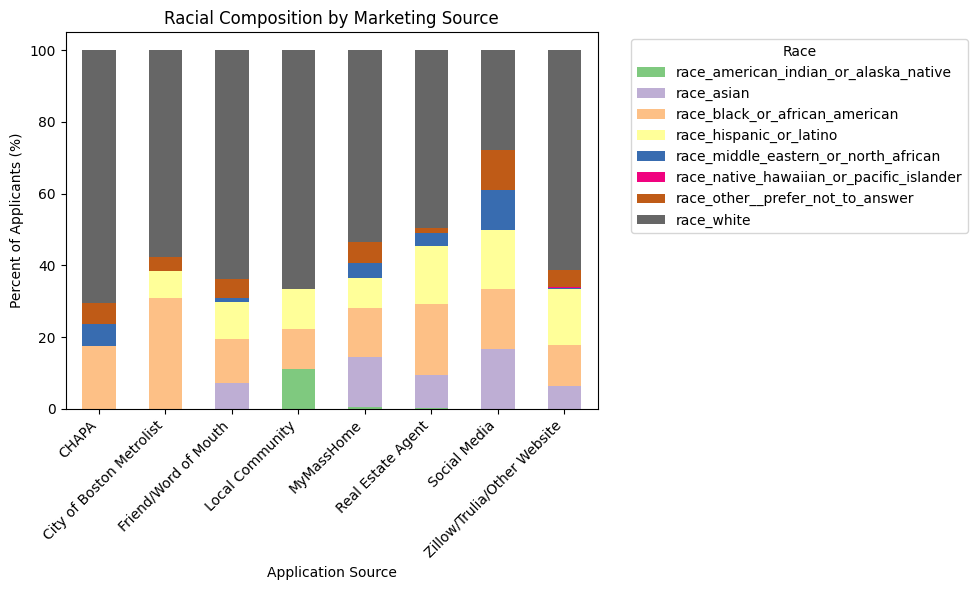

In [133]:
# Filter out unknowns
df_source = df[df['application_source'].notna() & (df['application_source'].str.lower() != 'unknown') & (df['race_type'] == 'Single Race')]

race_cols = df.columns.to_list()[-8:]

# Group by marketing source and sum race indicators
source_race = df_source.groupby('application_source')[race_cols].sum().reset_index()

# Convert to percentage within source
source_race_pct = source_race.copy()
source_race_pct[race_cols] = source_race[race_cols].div(source_race[race_cols].sum(axis=1), axis=0) * 100

source_race_pct.set_index('application_source')[race_cols].plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='Accent'
)
plt.ylabel('Percent of Applicants (%)')
plt.xlabel('Application Source')
plt.title('Racial Composition by Marketing Source')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

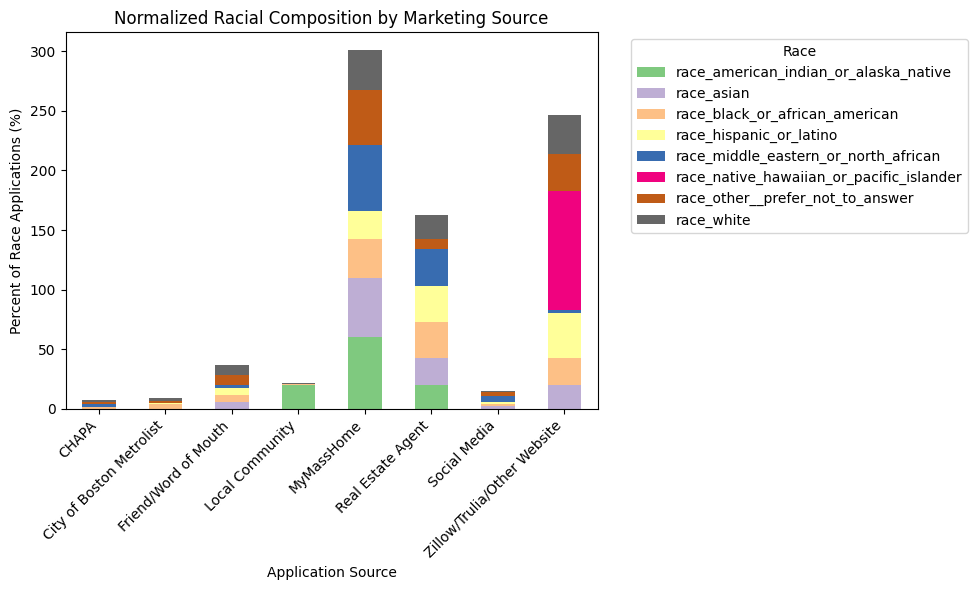

In [152]:
# Filter out unknowns and only single-race applicants
df_source = df[
    df['application_source'].notna() &
    (df['application_source'].str.lower() != 'unknown') &
    (df['race_type'] == 'Single Race')
]

# Identify one-hot race columns (last 8 columns)
race_cols = df_source.columns.to_list()[-8:]

# Group by marketing source and sum race indicators
source_race = df_source.groupby('application_source')[race_cols].sum()

# Normalize: divide by total applicants of each race (across all sources)
source_race_normalized = source_race.div(source_race.sum(axis=0), axis=1) * 100

# Plot normalized percentages
source_race_normalized.plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='Accent'
)
plt.ylabel('Percent of Race Applications (%)')
plt.xlabel('Application Source')
plt.title('Normalized Racial Composition by Marketing Source')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

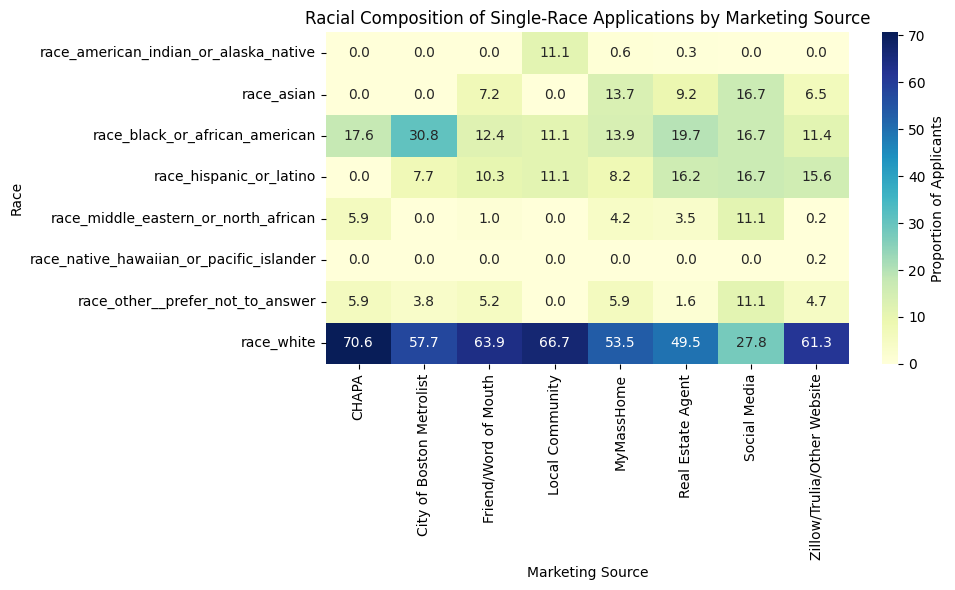

In [138]:
plt.figure(figsize=(10,6))
sns.heatmap(
    source_race_pct.set_index('application_source')[race_cols].T,
    cmap='YlGnBu', annot=True, fmt=".1f", cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Single-Race Applications by Marketing Source")
plt.ylabel("Race")
plt.xlabel("Marketing Source")
plt.tight_layout()
plt.show()

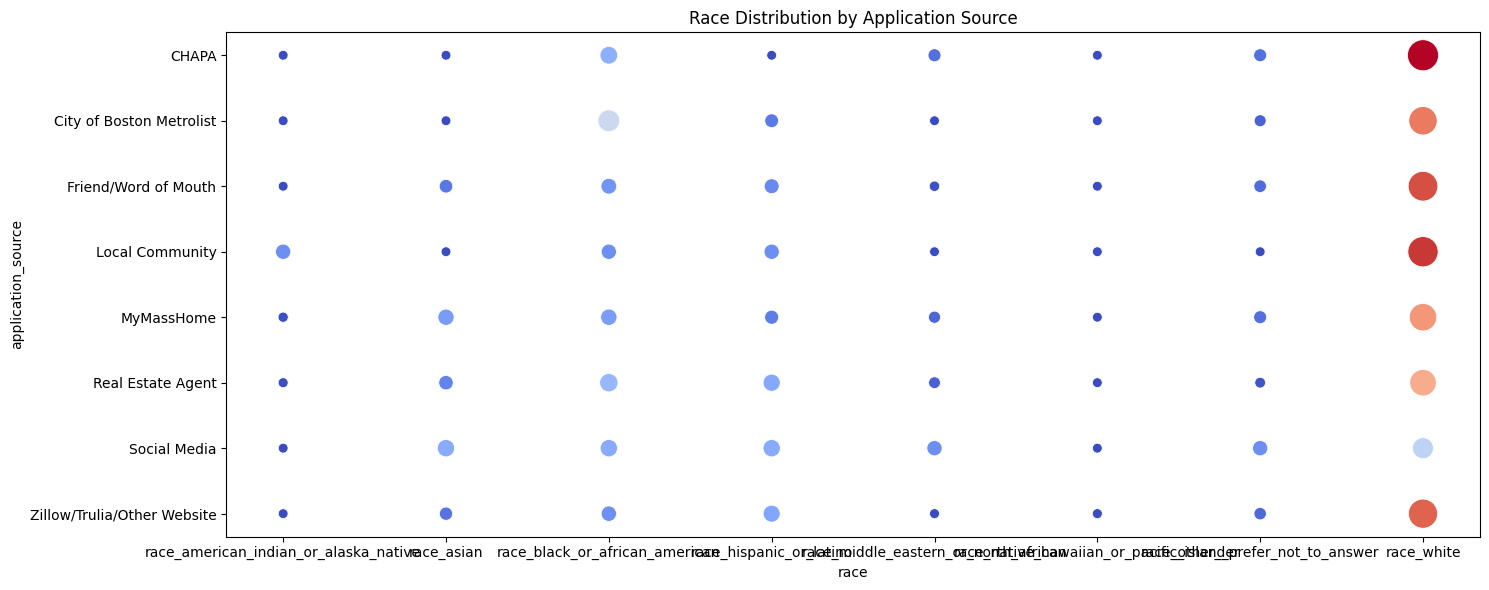

In [142]:
plt.figure(figsize=(15,6))
source_race_melt = source_race_pct.melt(id_vars='application_source', var_name='race', value_name='pct')
sns.scatterplot(
    data=source_race_melt, x='race', y='application_source',
    size='pct', hue='pct', sizes=(50, 500), palette='coolwarm', legend=False
)
plt.title('Race Distribution by Application Source')
plt.tight_layout()
plt.show()

In [143]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_source['application_source'], df_source['race_cleaned'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.2f}, p = {p:.4f}")

Chi-square = 124.41, p = 0.0000


In [144]:
import statsmodels.api as sm
from patsy import dmatrices

y, X = dmatrices('race_white ~ C(application_source)', data=df_source, return_type='dataframe')
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.678825
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             race_white   No. Observations:                 1360
Model:                          Logit   Df Residuals:                     1352
Method:                           MLE   Df Model:                            7
Date:                Fri, 07 Nov 2025   Pseudo R-squ.:                 0.01150
Time:                        00:34:40   Log-Likelihood:                -923.20
converged:                       True   LL-Null:                       -933.94
Covariance Type:            nonrobust   LLR p-value:                  0.003121
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept               

### Which Property is receiving the greatest Application count?

### MSA vs. Race

### Are older applicants applying because properties are age-restricted?

55+ applicants, age-restricted vs. non-age-restricted

## Testings

### Number of Applications by Marketing source

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_2998/4104255560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='application_source', order=df['application_source'].value_counts().index, palette='Set2')


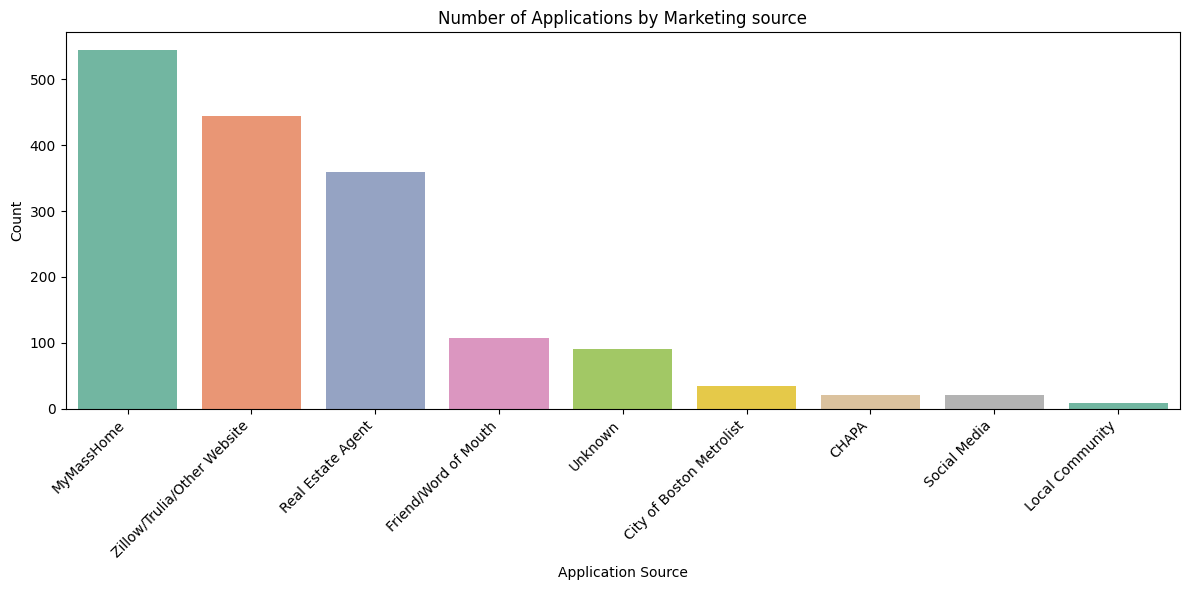

In [39]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='application_source', order=df['application_source'].value_counts().index, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Applications by Marketing source")
plt.ylabel("Count")
plt.xlabel("Application Source")
plt.tight_layout()
plt.show()

### Household Assets Distribution (Unique Applicants) (99th percentile)

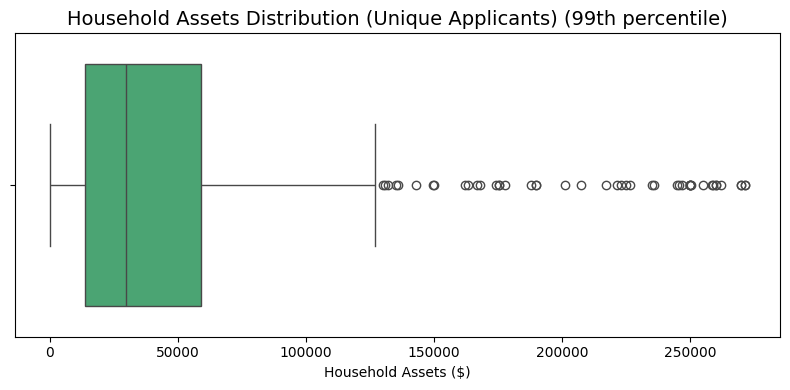

In [29]:
# Remove outlier and duplicates by id_number
df_unique = df[df['hh_assets'] < df['hh_assets'].quantile(0.99)].drop_duplicates(subset="id_number")

# Plot boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_unique["hh_assets"], color="mediumseagreen")
plt.title("Household Assets Distribution (Unique Applicants) (99th percentile)", fontsize=14)
plt.xlabel("Household Assets ($)")
plt.tight_layout()
plt.show()

### Proportion of First-time Homebuyers by Town

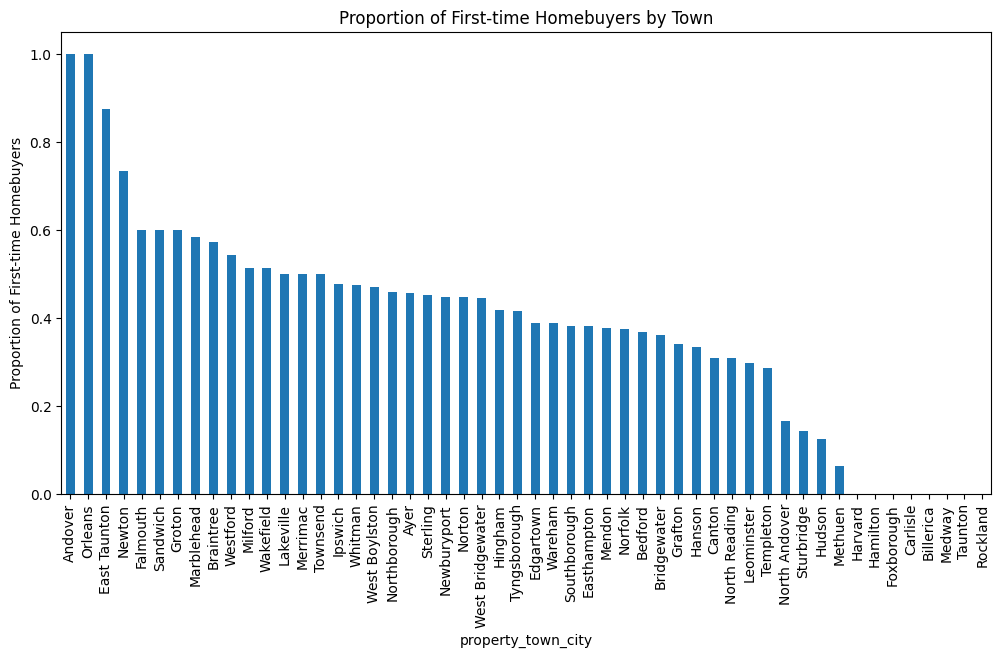

In [30]:
ftb_rate = df.groupby('property_town_city')['fthb_class'].mean().sort_values(ascending=False)
ftb_rate.plot(kind='bar', figsize=(12,6))
plt.ylabel("Proportion of First-time Homebuyers")
plt.title("Proportion of First-time Homebuyers by Town")
plt.show()

## New

* Supply-side constraint: demographics reflect where and what kinds of properties CHAPA offers (e.g., mostly suburban, age-restricted).

* Demand-side preference: demographics reflect who applies where (choices by age, race, income, household type, etc.).

### 1. Property-side demographics (supply)

**Goal:** Are certain towns or property types associated with particular demographic patterns?

Possible sub-questions:

* How do average applicant ages differ by property_town_city or msa?

* Are racial compositions (race_white, race_black_or_african_american, etc.) systematically different across towns?

* Are income brackets (hh_income, income_bracket) and asset levels higher for certain property locations (suburban vs urban)?

* For age-restricted properties, are applicants older on average?

#### How do average applicant ages differ by property_town_city or msa?

In [150]:
cv_by_town = age_by_town['avg_age'].std() / age_by_town['avg_age'].mean()
print(f"CV across towns: {cv_by_town:.2f}")
# If the CV is large (>0.15), it implies meaningful town-level age variation — likely reflecting property characteristics (e.g., retirement vs family housing).

CV across towns: 0.25


In [151]:
model = smf.ols('age ~ C(property_town_city) + hh_income + hh_assets', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     9.950
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           1.72e-66
Time:                        00:55:41   Log-Likelihood:                -6260.5
No. Observations:                1609   AIC:                         1.263e+04
Df Residuals:                    1555   BIC:                         1.292e+04
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 2. Applicant-side choice patterns (demand)

**Goal:** Do different demographic groups apply to different types of properties?

Possible sub-questions:

* Do younger applicants (or those with dependents) tend to apply to certain towns or non-age-restricted homes?

* Do lower-income households apply more to certain regions or MSAs?

* Are certain race groups concentrated among applicants to specific towns or property types?

* How does household size or type (hh_size, dependents, hh_type) influence which properties are chosen?

### 3. Comparing applicant pool vs property pool

**Goal:** Is the demographic mix of applicants explained by the properties offered?

Possible sub-questions:

* If some towns have few properties but many applicants, does that skew racial/age representation?

* Are demographics within each town consistent across properties, or do certain properties attract distinct subgroups?

* Compare town demographics of applicants vs census_races for that town (you have census_races column).